## Phase 1. Data Collection

In [1]:
from google.colab import files

uploaded = files.upload()

Saving kc_house_data.csv to kc_house_data.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.compose import ColumnTransformer

import torch
from torch.utils.data import TensorDataset

In [5]:
df = pd.read_csv("kc_house_data.csv")

In [7]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (17290, 21)
Validation: (2161, 21)
Test: (2162, 21)


In [8]:
train_df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
6325,5467910190,20140527T000000,325000.0,3,1.75,1780,13095,1.0,0,0,...,9,1780,0,1983,0,98042,47.3670,-122.152,2750,13095
13473,9331800580,20150310T000000,257000.0,2,1.00,1000,3700,1.0,0,0,...,6,800,200,1929,0,98118,47.5520,-122.290,1270,5000
17614,2407000405,20150226T000000,228500.0,3,1.00,1080,7486,1.5,0,0,...,6,990,90,1942,0,98146,47.4838,-122.335,1170,7800
16970,5466700290,20150108T000000,288000.0,3,2.25,2090,7500,1.0,0,0,...,7,1280,810,1977,0,98031,47.3951,-122.172,1800,7350
20868,3026059361,20150417T000000,479000.0,2,2.50,1741,1439,2.0,0,0,...,8,1446,295,2007,0,98034,47.7043,-122.209,2090,10454


In [9]:
train_df.shape

(17290, 21)

In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17290 entries, 6325 to 15795
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             17290 non-null  int64  
 1   date           17290 non-null  object 
 2   price          17290 non-null  float64
 3   bedrooms       17290 non-null  int64  
 4   bathrooms      17290 non-null  float64
 5   sqft_living    17290 non-null  int64  
 6   sqft_lot       17290 non-null  int64  
 7   floors         17290 non-null  float64
 8   waterfront     17290 non-null  int64  
 9   view           17290 non-null  int64  
 10  condition      17290 non-null  int64  
 11  grade          17290 non-null  int64  
 12  sqft_above     17290 non-null  int64  
 13  sqft_basement  17290 non-null  int64  
 14  yr_built       17290 non-null  int64  
 15  yr_renovated   17290 non-null  int64  
 16  zipcode        17290 non-null  int64  
 17  lat            17290 non-null  float64
 18  long    

In [11]:
train_df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,1.729000e+04,1.729000e+04,17290.000000,17290.000000,17290.000000,1.729000e+04,17290.000000,17290.000000,17290.000000,17290.000000,17290.000000,17290.000000,17290.000000,17290.000000,17290.000000,17290.000000,17290.000000,17290.000000,17290.000000,17290.000000
mean,4.580764e+09,5.377680e+05,3.368132,2.113794,2073.894910,1.479895e+04,1.499161,0.007172,0.233025,3.407577,7.653846,1785.962175,287.932736,1971.108329,83.003412,98077.974378,47.560330,-122.214139,1982.904569,12725.059341
std,2.876743e+09,3.614639e+05,0.931385,0.766790,907.297963,3.883925e+04,0.542819,0.084385,0.761749,0.651698,1.170355,821.626290,438.727110,29.435603,398.503250,53.326084,0.138432,0.140498,681.232425,27525.258285
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.159300,-122.519000,399.000000,651.000000
25%,2.123042e+09,3.201500e+05,3.000000,1.500000,1430.000000,5.001250e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1200.000000,0.000000,1951.000000,0.000000,98033.000000,47.472000,-122.329000,1480.000000,5083.000000
50%,3.905000e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.600000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.231000,1840.000000,7615.000000
75%,7.305301e+09,6.400000e+05,4.000000,2.500000,2540.000000,1.060675e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2200.000000,550.000000,1997.000000,0.000000,98117.000000,47.678000,-122.125000,2360.000000,10046.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,12050.000000,1.164794e+06,3.500000,1.000000,4.000000,5.000000,13.000000,8860.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## PHASE 2: Chia Train / Validation / Test

In [57]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

In [58]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

In [59]:
print(
    train_df.shape
)

print(
    val_df.shape
)

print(
    test_df.shape
)

(17290, 21)
(2161, 21)
(2162, 21)


##PHASE 3: EDA (Khám phá dữ liệu)

In [12]:
train_df.isnull().sum()

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


In [13]:
train_df.duplicated().sum()

np.int64(0)

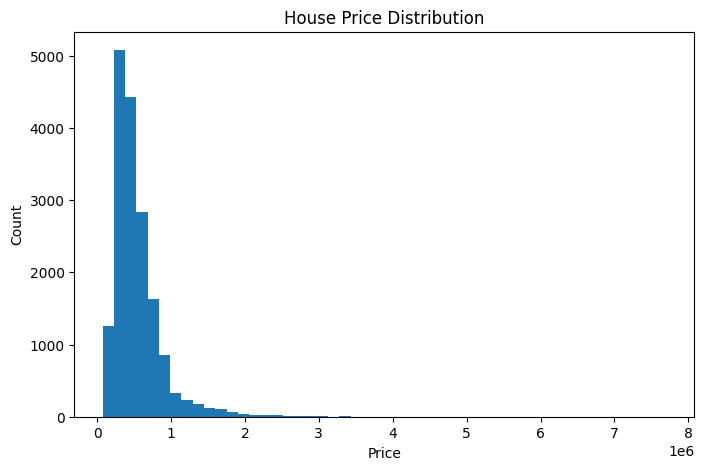

In [14]:
plt.figure(figsize=(8,5))

plt.hist(
    train_df["price"],
    bins=50
)

plt.xlabel("Price")
plt.ylabel("Count")

plt.title("House Price Distribution")

plt.show()

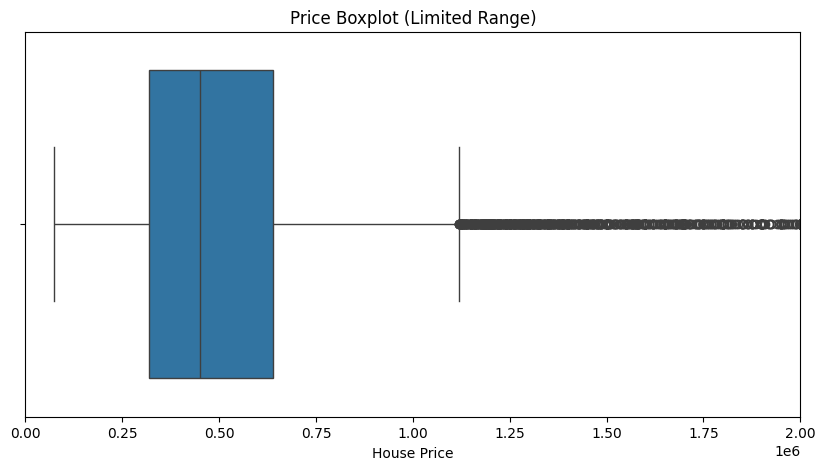

In [18]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=train_df["price"]
)

plt.xlim(0, 2000000)   # chỉ xem nhà dưới 2 triệu

plt.title("Price Boxplot (Limited Range)")
plt.xlabel("House Price")

plt.show()

In [19]:
corr = train_df.corr(
    numeric_only=True
)

corr["price"].sort_values(
    ascending=False
)

,price
price,1.000000
sqft_living,0.701701
grade,0.665093
sqft_above,0.603255
sqft_living15,0.582667
bathrooms,0.526618
view,0.392108
sqft_basement,0.321387
lat,0.310770
bedrooms,0.308262


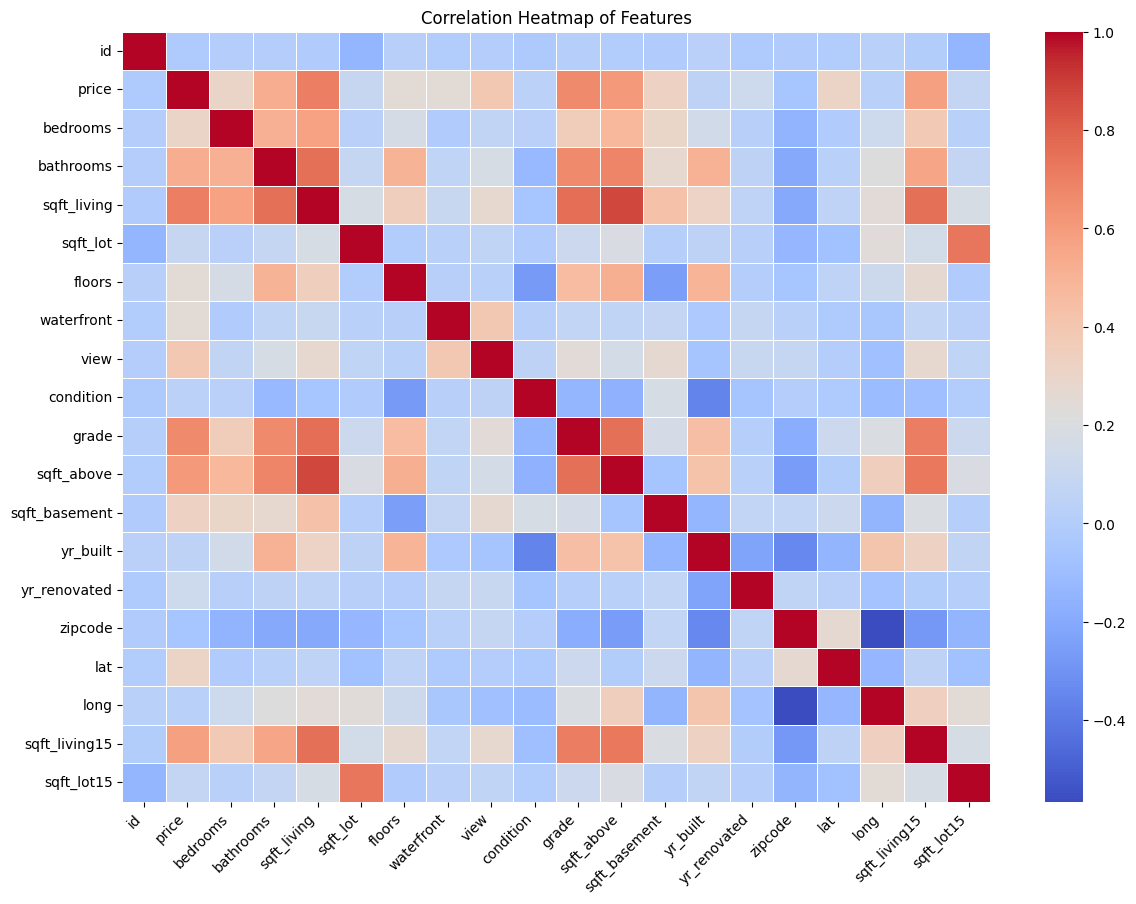

In [21]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Features")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.show()

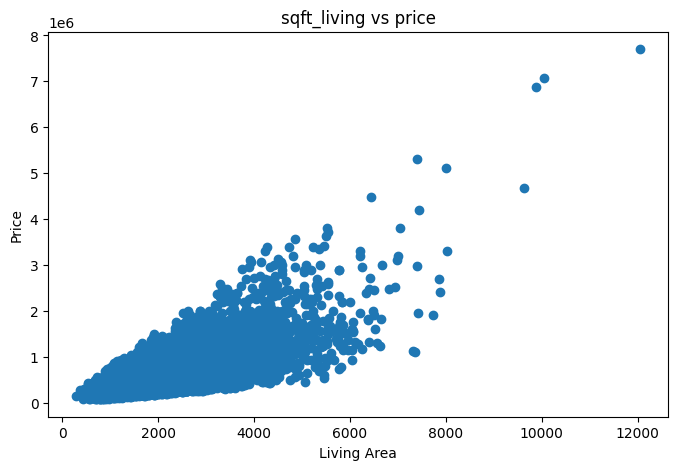

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(
    train_df["sqft_living"],
    train_df["price"]
)

plt.xlabel("Living Area")
plt.ylabel("Price")

plt.title(
    "sqft_living vs price"
)

plt.show()

In [ ]:
##PHASE 4: Data Cleaning

In [61]:
train_df = train_df.drop_duplicates()

In [24]:
train_df.isnull().sum()

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


In [25]:
train_df.dtypes

,0
id,int64
date,object
price,float64
bedrooms,int64
bathrooms,float64
sqft_living,int64
sqft_lot,int64
floors,float64
waterfront,int64
view,int64


In [27]:
train_df["date"] = pd.to_datetime(
    train_df["date"]
)

In [28]:
train_df["date"].head()

,date
6325,2014-05-27
13473,2015-03-10
17614,2015-02-26
16970,2015-01-08
20868,2015-04-17


In [29]:
train_df["sale_year"] = (
    train_df["date"].dt.year
)
train_df["sale_month"] = (
    train_df["date"].dt.month
)

In [30]:
train_df[
["date","sale_year","sale_month"]
].head()

,date,sale_year,sale_month
6325,2014-05-27,2014,5
13473,2015-03-10,2015,3
17614,2015-02-26,2015,2
16970,2015-01-08,2015,1
20868,2015-04-17,2015,4


In [31]:
train_df.drop(
    "date",
    axis=1,
    inplace=True
)

In [32]:
train_df["id"].head()

,id
6325,5467910190
13473,9331800580
17614,2407000405
16970,5466700290
20868,3026059361


In [33]:
train_df.drop(
    "id",
    axis=1,
    inplace=True
)

In [34]:
train_df["bedrooms"].value_counts()

,count
bedrooms,
3,7865
4,5477
2,2237
5,1292
6,212
1,153
7,29
8,9
0,8


In [35]:
train_df["bathrooms"].describe()

,bathrooms
count,17290.000000
mean,2.113794
std,0.766790
min,0.000000
25%,1.500000
50%,2.250000
75%,2.500000
max,8.000000


In [36]:
train_df = train_df[
    train_df["bathrooms"] > 0
]

In [37]:
train_df["price"].describe()

,price
count,1.728300e+04
mean,5.378240e+05
std,3.614413e+05
min,7.800000e+04
25%,3.209000e+05
50%,4.500000e+05
75%,6.400000e+05
max,7.700000e+06


In [38]:
train_df[
train_df["price"] < 50000
]

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month


In [39]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17283 entries, 6325 to 15795
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          17283 non-null  float64
 1   bedrooms       17283 non-null  int64  
 2   bathrooms      17283 non-null  float64
 3   sqft_living    17283 non-null  int64  
 4   sqft_lot       17283 non-null  int64  
 5   floors         17283 non-null  float64
 6   waterfront     17283 non-null  int64  
 7   view           17283 non-null  int64  
 8   condition      17283 non-null  int64  
 9   grade          17283 non-null  int64  
 10  sqft_above     17283 non-null  int64  
 11  sqft_basement  17283 non-null  int64  
 12  yr_built       17283 non-null  int64  
 13  yr_renovated   17283 non-null  int64  
 14  zipcode        17283 non-null  int64  
 15  lat            17283 non-null  float64
 16  long           17283 non-null  float64
 17  sqft_living15  17283 non-null  int64  
 18  sqft_lot

In [40]:
train_df.to_csv(
    "clean_house_data.csv",
    index=False
)

##Phase 5: Feature Engineering.

In [42]:
id="houseage1"
train_df["house_age"] = (
    train_df["sale_year"] - train_df["yr_built"]
)
id="houseage2"
train_df[
["yr_built","sale_year","house_age"]
].head()

,yr_built,sale_year,house_age
6325,1983,2014,31
13473,1929,2015,86
17614,1942,2015,73
16970,1977,2015,38
20868,2007,2015,8


In [62]:
train_df["renovated"] = (
    train_df["yr_renovated"] > 0
).astype(int)

train_df[["yr_renovated","renovated"]].head()

,yr_renovated,renovated
6325,0,0
13473,0,0
17614,0,0
16970,0,0
20868,0,0


In [63]:
train_df["living_lot_ratio"] = (
    train_df["sqft_living"] /
    train_df["sqft_lot"]
)

train_df[
    ["sqft_living","sqft_lot","living_lot_ratio"]
].head()

,sqft_living,sqft_lot,living_lot_ratio
6325,1780,13095,0.135930
13473,1000,3700,0.270270
17614,1080,7486,0.144269
16970,2090,7500,0.278667
20868,1741,1439,1.209868


In [64]:
train_df["price_per_sqft"] = (
    train_df["price"] /
    train_df["sqft_living"]
)

train_df[
    ["price","sqft_living","price_per_sqft"]
].head()

,price,sqft_living,price_per_sqft
6325,325000.0,1780,182.584270
13473,257000.0,1000,257.000000
17614,228500.0,1080,211.574074
16970,288000.0,2090,137.799043
20868,479000.0,1741,275.129236


In [65]:
train_df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,renovated,living_lot_ratio,price_per_sqft
6325,5467910190,20140527T000000,325000.0,3,1.75,1780,13095,1.0,0,0,...,1983,0,98042,47.3670,-122.152,2750,13095,0,0.135930,182.584270
13473,9331800580,20150310T000000,257000.0,2,1.00,1000,3700,1.0,0,0,...,1929,0,98118,47.5520,-122.290,1270,5000,0,0.270270,257.000000
17614,2407000405,20150226T000000,228500.0,3,1.00,1080,7486,1.5,0,0,...,1942,0,98146,47.4838,-122.335,1170,7800,0,0.144269,211.574074
16970,5466700290,20150108T000000,288000.0,3,2.25,2090,7500,1.0,0,0,...,1977,0,98031,47.3951,-122.172,1800,7350,0,0.278667,137.799043
20868,3026059361,20150417T000000,479000.0,2,2.50,1741,1439,2.0,0,0,...,2007,0,98034,47.7043,-122.209,2090,10454,0,1.209868,275.129236


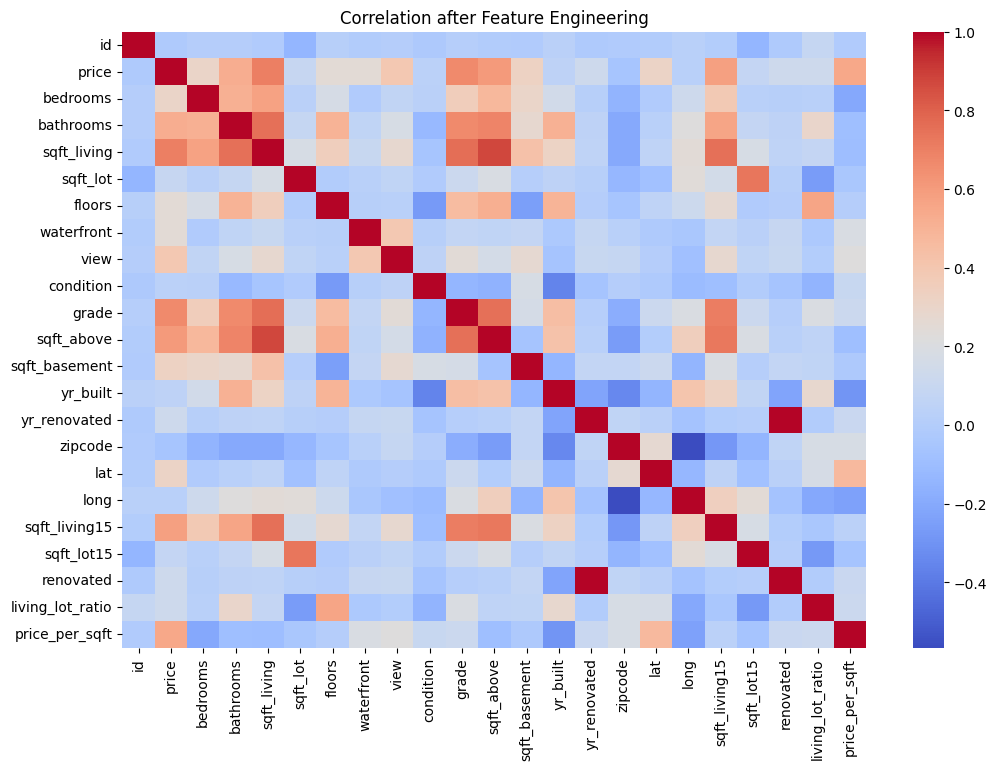

In [68]:
plt.figure(figsize=(12,8))

sns.heatmap(
    train_df.select_dtypes(include="number").corr(),
    cmap="coolwarm"
)

plt.title("Correlation after Feature Engineering")

plt.show()

##Phase 6: Split Data into X và y.

In [69]:
##Tách X và Y
X = train_df.drop("price", axis=1)
y = train_df["price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (17290, 23)
y shape: (17290,)


In [70]:
##Kiểm tra Feature trong x
X.head()

,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,renovated,living_lot_ratio,price_per_sqft
6325,5467910190,20140527T000000,3,1.75,1780,13095,1.0,0,0,4,...,1983,0,98042,47.3670,-122.152,2750,13095,0,0.135930,182.584270
13473,9331800580,20150310T000000,2,1.00,1000,3700,1.0,0,0,3,...,1929,0,98118,47.5520,-122.290,1270,5000,0,0.270270,257.000000
17614,2407000405,20150226T000000,3,1.00,1080,7486,1.5,0,0,3,...,1942,0,98146,47.4838,-122.335,1170,7800,0,0.144269,211.574074
16970,5466700290,20150108T000000,3,2.25,2090,7500,1.0,0,0,4,...,1977,0,98031,47.3951,-122.172,1800,7350,0,0.278667,137.799043
20868,3026059361,20150417T000000,2,2.50,1741,1439,2.0,0,0,3,...,2007,0,98034,47.7043,-122.209,2090,10454,0,1.209868,275.129236


In [71]:
##Kiểm tra y
y.head()

,price
6325,325000.0
13473,257000.0
17614,228500.0
16970,288000.0
20868,479000.0


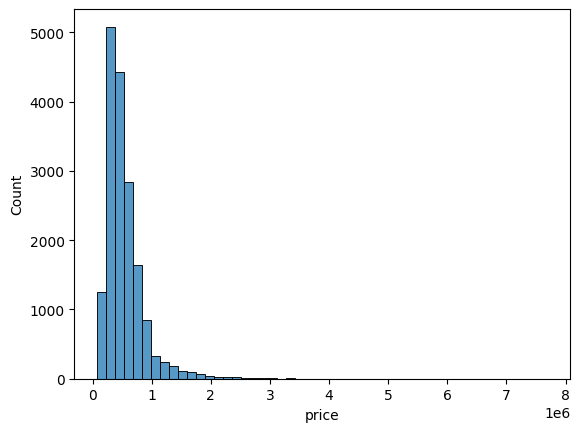

In [72]:
sns.histplot(y, bins=50)
plt.show()

##Phase 7: Preprocessing Pipeline bằng scikit-learn.

In [74]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [75]:
##Xác định cột số và cột dạng category
numeric_features = X.select_dtypes(
    include=["int64","float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns


print("Numeric:")
print(numeric_features)

print("\nCategorical:")
print(categorical_features)

Numeric:
Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'renovated', 'living_lot_ratio',
       'price_per_sqft'],
      dtype='object')

Categorical:
Index(['date'], dtype='object')


In [76]:
##Tạo pipeline
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

In [ ]:
##Pipeline cho categorical
categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

In [79]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

numeric_features = X.columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        )
    ]
)

In [81]:
id="checkx"
X.dtypes

,0
id,int64
date,object
bedrooms,int64
bathrooms,float64
sqft_living,int64
sqft_lot,int64
floors,float64
waterfront,int64
view,int64
condition,int64


In [82]:
id="objectcol"
X.select_dtypes(include="object").columns

Index(['date'], dtype='object')

In [83]:
id="onlynumber"
X = X.select_dtypes(
    include=["int64","float64"]
)

print(X.shape)

(17290, 22)


In [84]:
id="scaleragain"
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_processed = scaler.fit_transform(X)

print(X_processed.shape)

(17290, 22)


##Phase 8: Feature Scaling.

In [85]:
##Kiểm tra dữ liệu trước scaling
X.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,renovated,living_lot_ratio,price_per_sqft
6325,5467910190,3,1.75,1780,13095,1.0,0,0,4,9,...,1983,0,98042,47.3670,-122.152,2750,13095,0,0.135930,182.584270
13473,9331800580,2,1.00,1000,3700,1.0,0,0,3,6,...,1929,0,98118,47.5520,-122.290,1270,5000,0,0.270270,257.000000
17614,2407000405,3,1.00,1080,7486,1.5,0,0,3,6,...,1942,0,98146,47.4838,-122.335,1170,7800,0,0.144269,211.574074
16970,5466700290,3,2.25,2090,7500,1.0,0,0,4,7,...,1977,0,98031,47.3951,-122.172,1800,7350,0,0.278667,137.799043
20868,3026059361,2,2.50,1741,1439,2.0,0,0,3,8,...,2007,0,98034,47.7043,-122.209,2090,10454,0,1.209868,275.129236


In [86]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [87]:
print(X_scaled[:5])

[[ 3.08394565e-01 -3.95263347e-01 -4.74451435e-01 -3.23932624e-01
  -4.38730591e-02 -9.19599765e-01 -8.49916555e-02 -3.05916511e-01
   9.09072679e-01  1.15024328e+00 -7.25676280e-03 -6.56310167e-01
   4.04001074e-01 -2.08293942e-01 -6.74630801e-01 -1.39660754e+00
   4.42288468e-01  1.12607326e+00  1.34404318e-02 -2.08300392e-01
  -7.01002545e-01 -7.40650735e-01]
 [ 1.65158104e+00 -1.46896378e+00 -1.45258323e+00 -1.18365301e+00
  -2.85774539e-01 -9.19599765e-01 -8.49916555e-02 -3.05916511e-01
  -6.25425673e-01 -1.41315603e+00 -1.20004764e+00 -2.00432744e-01
  -1.43056508e+00 -2.08293942e-01  7.50604140e-01 -6.01724805e-02
  -5.39958208e-01 -1.04652268e+00 -2.80661590e-01 -2.08300392e-01
  -2.05433018e-01 -6.37775061e-02]
 [-7.55655451e-01 -3.95263347e-01 -1.45258323e+00 -1.09547656e+00
  -1.88293006e-01  1.54500858e-03 -8.49916555e-02 -3.05916511e-01
  -6.25425673e-01 -1.41315603e+00 -9.68792265e-01 -4.51165327e-01
  -9.88910265e-01 -2.08293942e-01  1.27569070e+00 -5.52847460e-01
  -8.6

In [88]:
print(
    X_scaled.mean()
)

print(
    X_scaled.std()
)

6.530500065913101e-15
0.9999999999999999


In [89]:
input_size = X_scaled.shape[1]

print(input_size)

22


In [91]:
from sklearn.model_selection import train_test_split


X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

In [92]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(13832, 22)
(1729, 22)
(1729, 22)


##Phase 9: Create PyTorch Dataset

In [93]:
import torch
from torch.utils.data import TensorDataset, DataLoader

In [94]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

In [95]:
y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val.values,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
)

In [96]:
y_train_tensor = y_train_tensor.reshape(-1,1)

y_val_tensor = y_val_tensor.reshape(-1,1)

y_test_tensor = y_test_tensor.reshape(-1,1)

In [97]:
print(X_train_tensor.shape)
print(y_train_tensor.shape)

print(X_val_tensor.shape)
print(y_val_tensor.shape)

print(X_test_tensor.shape)
print(y_test_tensor.shape)

torch.Size([13832, 22])
torch.Size([13832, 1])
torch.Size([1729, 22])
torch.Size([1729, 1])
torch.Size([1729, 22])
torch.Size([1729, 1])


In [98]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

In [99]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

13832
1729
1729
